In [1]:
import os 
import torch 
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import random
import sys
import os

In [2]:
sys.path.append(os.path.abspath(os.path.join('..')))

In [3]:
from src.utils import set_seed

set_seed()

In [4]:
clases_indice = {'Windshield Fluid': 0, 'Engine': 1, 'Battery': 2, 'Engine Cover': 3, 'Air Filter': 4, 'Reservoir Cap': 5, 'Coolant Reservoir': 6}
indice_clases = {0:'Windshield Fluid', 1:'Engine', 2:'Battery', 3:'Engine Cover', 4:'Air Filter', 5:'Reservoir Cap', 6:'Coolant Reservoir',}

In [5]:
from src.utils import preprocesado_imagen

directorio = "../data/Toyota Corolla Dataset"
X = []
y = []
for carpeta in os.listdir(directorio):
    ruta_carpeta = os.path.join(directorio, carpeta)
    for imagen in os.listdir(os.path.join(ruta_carpeta)):
        if not imagen.endswith(".Identifier"):
            ruta_completa = os.path.join(ruta_carpeta, imagen)
            image = preprocesado_imagen(ruta_completa)
            X.append(image)
            y.append(clases_indice[carpeta])

In [6]:
from src.dataset import ImagenDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
dataset_imagenes = ImagenDataset(X, y)

In [8]:
torch.save(dataset_imagenes, "../data/dataset_preprocesado.pt")

In [9]:
dataset_imagenes = torch.load("../data/dataset_preprocesado.pt", weights_only=False)

In [10]:
len_train = int(len(dataset_imagenes) * 0.8)
len_val = int(len(dataset_imagenes) * 0.1)
len_test = len(dataset_imagenes) - len_train - len_val

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset_imagenes,(len_train, len_val, len_test))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True, prefetch_factor=2, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True, prefetch_factor=2, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True, prefetch_factor=2, persistent_workers=True)

In [11]:
from models.modelo import Modelo

modelo = Modelo().to(device)
lossfn = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelo.parameters(), lr=0.0005)
num_epochs = 100
patience = 7

/home/mateo/miniconda3/envs/Proenv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/mateo/miniconda3/envs/Proenv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [12]:
import time

def calculate_accuracy(model, data_, K=1):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in data_:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            topk = outputs.topk(K, dim=1)[1]
            correct_mask = topk.eq(targets.view(-1, 1).expand_as(topk))
            correct += correct_mask.sum().item()
            total += targets.size(0)

    accuracy = correct / total
    return accuracy

def train_model(model, optimizer, lossfn, train_loader, val_loader, patience, num_epochs):
    no_improvement = 0
    min_loss = float('inf')
    for epoch in range(num_epochs):
        start_time = time.time()

        total_train_loss = 0
        total_val_loss = 0

        model.train()
        for inputs, targets in train_loader: 
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = lossfn(outputs, targets)
            loss.backward()  
            optimizer.step()
            total_train_loss += loss.item()

        train_accuracy = calculate_accuracy(model, train_loader)

        model.eval()
        with torch.no_grad():
            for inputs, targets in val_loader:
                targets = torch.tensor(targets, dtype=torch.long)
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = lossfn(outputs, targets)
                total_val_loss += loss.item()

        val_accuracy = calculate_accuracy(model, val_loader)
        val_accuracy_3 = calculate_accuracy(model, val_loader, K=3)

        epoch_time = time.time() - start_time

        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {total_train_loss/len(train_loader):.4f}, '
              f'Val Loss: {total_val_loss/len(val_loader):.4f}, '
              f'Train T1 Accuracy: {train_accuracy:.4f}, '
              f'Val T1 Accuracy: {val_accuracy:.4f}, '
              f'Val T3 Accuracy: {val_accuracy_3:.4f}, '
              f'Time: {epoch_time:.2f} sec')
        
        if total_val_loss < min_loss:
            min_loss = total_val_loss
            no_improvement = 0
        else:
            no_improvement += 1
        
        if no_improvement >= patience:
            print(f"No hay mejora por {patience} épocas. Parada Temprana!!")
            break

print(f"Entrenando CNN en {device}...")
train_model(modelo, optimizer, lossfn, train_loader, val_loader, patience, num_epochs)

Entrenando CNN en cuda...


/tmp/ipykernel_2032/2106564487.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  targets = torch.tensor(targets, dtype=torch.long)


Epoch [1/100], Train Loss: 1.8076, Val Loss: 1.5391, Train T1 Accuracy: 0.4903, Val T1 Accuracy: 0.4296, Val T3 Accuracy: 0.8074, Time: 4.69 sec
Epoch [2/100], Train Loss: 1.3905, Val Loss: 0.9371, Train T1 Accuracy: 0.6938, Val T1 Accuracy: 0.7037, Val T3 Accuracy: 0.9556, Time: 2.45 sec
Epoch [3/100], Train Loss: 0.8637, Val Loss: 0.4752, Train T1 Accuracy: 0.8770, Val T1 Accuracy: 0.8889, Val T3 Accuracy: 0.9852, Time: 2.38 sec
Epoch [4/100], Train Loss: 0.5313, Val Loss: 0.3261, Train T1 Accuracy: 0.9056, Val T1 Accuracy: 0.8667, Val T3 Accuracy: 0.9852, Time: 2.39 sec
Epoch [5/100], Train Loss: 0.3888, Val Loss: 0.2620, Train T1 Accuracy: 0.9288, Val T1 Accuracy: 0.8889, Val T3 Accuracy: 0.9778, Time: 2.30 sec
Epoch [6/100], Train Loss: 0.2883, Val Loss: 0.2197, Train T1 Accuracy: 0.9482, Val T1 Accuracy: 0.9185, Val T3 Accuracy: 0.9852, Time: 2.36 sec
Epoch [7/100], Train Loss: 0.2371, Val Loss: 0.2061, Train T1 Accuracy: 0.9537, Val T1 Accuracy: 0.9111, Val T3 Accuracy: 0.9852, 

In [13]:
test_accuracy = calculate_accuracy(modelo, test_loader)
print(f"Accuracy en cojunto de test {test_accuracy:.4f}")

Accuracy en cojunto de test 0.9044


In [14]:
ruta_modelo = "../models/modelo_corolla.pth"
torch.save(modelo.state_dict(), ruta_modelo)
print(f"Modelo guardado en {ruta_modelo}")

Modelo guardado en ../models/modelo_corolla.pth


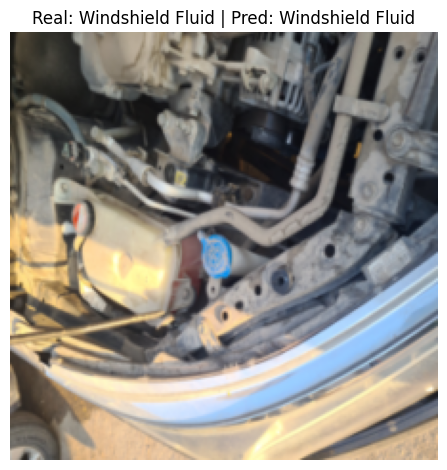

In [15]:
import matplotlib.pyplot as plt

indx = random.randint(0, len(test_dataset)-1)
imagen, etiqueta = test_dataset[indx]
imagen = imagen.to(device)
modelo.eval()
with torch.no_grad():
    output = modelo(imagen.unsqueeze(0))
imagen = imagen.to('cpu')
pred = output.argmax(1).item()
mean = torch.tensor([0.485, 0.456, 0.406]) 
std = torch.tensor([0.229, 0.224, 0.225]) 
imagen_n = imagen * std[:, None, None] + mean[:, None, None]
imagen_n = imagen_n.permute(1, 2, 0)
plt.imshow(imagen_n.squeeze())
plt.title(f"Real: {indice_clases[etiqueta]} | Pred: {indice_clases[pred]}")
plt.axis('off')
plt.tight_layout()
plt.show()

In [16]:
from lime import lime_image

explainer = lime_image.LimeImageExplainer()
def predict_fn(images):
    modelo.eval()
    batch = []

    for img in images:
        # img es numpy HWC en rango [0,1]
        img = torch.tensor(img).permute(2, 0, 1).float()

        # Normalizar igual que en tu dataset
        img = (img - mean[:, None, None]) / std[:, None, None]

        batch.append(img)

    batch = torch.stack(batch).to(device)

    with torch.no_grad():
        outputs = modelo(batch)
        probs = torch.softmax(outputs, dim=1)

    return probs.cpu().numpy()


/home/mateo/miniconda3/envs/Proenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
imagen_n = imagen_n.cpu().numpy()
explanation = explainer.explain_instance(imagen_n, 
                                         predict_fn, 
                                         hide_color=0, 
                                         top_labels=1,
                                         num_samples=2000)

100%|██████████| 2000/2000 [00:07<00:00, 273.24it/s]


In [18]:
[indice_clases[i] for i in explanation.top_labels]

['Windshield Fluid']

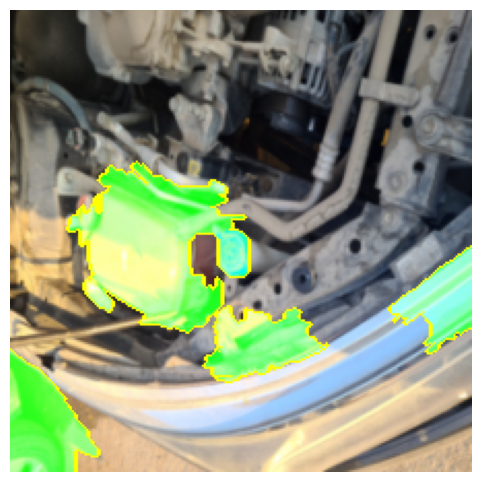

In [19]:
from skimage.segmentation import mark_boundaries

# Display the explanation using matplotlib
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], 
                                            positive_only=False, 
                                            num_features=5, 
                                            hide_rest=False)
# Asegurar rango correcto 
temp = temp.astype(float) 
temp = (temp - temp.min()) / (temp.max() - temp.min() + 1e-8) 
plt.figure(figsize=(6,6)) 
plt.imshow(mark_boundaries(temp, mask)) 
plt.axis('off') 
plt.show()

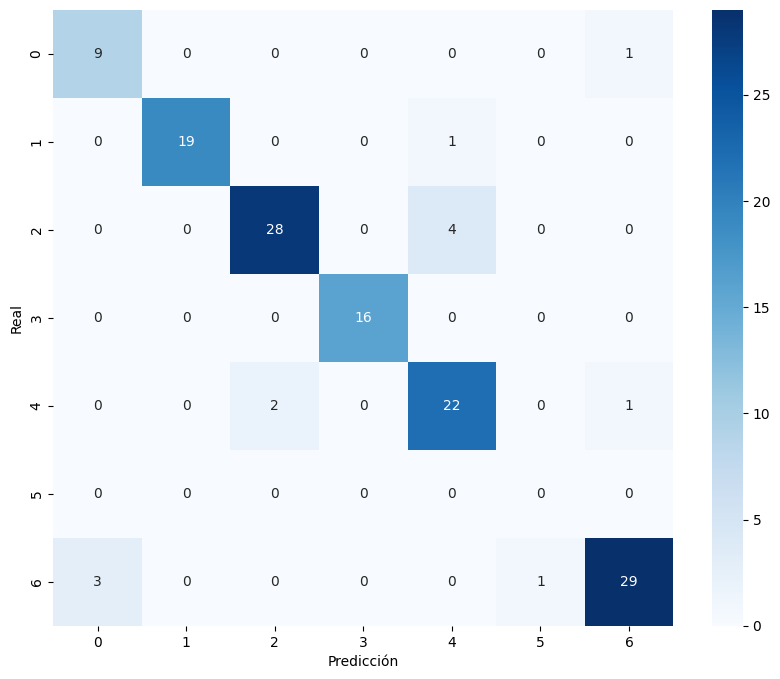

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, loader):
    y_true = []
    y_pred = []
    model.eval()
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(targets.numpy())
            y_pred.extend(preds.cpu().numpy())
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

plot_confusion_matrix(modelo, test_loader)